In [1]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

In [2]:
from langgraph.graph import START ,END,StateGraph
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage,BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence

/opt/anaconda3/envs/langgraph_env/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
class State(TypedDict):
    messages:Sequence[BaseMessage]

In [4]:
state=State(messages=[HumanMessage("Could you tell me a grook by piet hein")])

In [5]:
state["messages"][0].pretty_print()

================================ Human Message =================================

Could you tell me a grook by piet hein


In [6]:
chat=ChatOpenAIchat = ChatOpenAI(model = "gpt-4o", 
                  seed = 365, 
                  temperature = 0, 
                  max_completion_tokens = 100)

In [7]:
response=chat.invoke(state["messages"])

In [8]:
response.pretty_print()

================================== Ai Message ==================================

Certainly! Here's a classic grook by Piet Hein:

```
Losing One Glove

Losing one glove
is certainly painful,
but nothing
compared to the pain
of losing one,
throwing away the other,
and finding
the first one again.
```

Piet Hein's grooks are known for their brevity and wit, often conveying deep insights with simplicity.


In [9]:
def chatbot(state:State)-> State:
    print(f"\n----------->Entering chatbot:")
    response=chat.invoke(state["messages"])
    response.pretty_print()
    return State(messages=[response])

In [10]:
chatbot(state)


----------->Entering chatbot:
================================== Ai Message ==================================

Certainly! Here's a classic grook by Piet Hein:

```
Losing One Glove

Losing one glove
is certainly painful,
but nothing
compared to the pain
of losing one,
throwing away the other,
and finding
the first one again.
```

Piet Hein's grooks are known for their brevity and wit, often conveying deep insights with simplicity.


{'messages': [AIMessage(content="Certainly! Here's a classic grook by Piet Hein:\n\n```\nLosing One Glove\n\nLosing one glove\nis certainly painful,\nbut nothing\ncompared to the pain\nof losing one,\nthrowing away the other,\nand finding\nthe first one again.\n```\n\nPiet Hein's grooks are known for their brevity and wit, often conveying deep insights with simplicity.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 17, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d59908c1a9', 'id': 'chatcmpl-DWGhA6HB2ZSMtNnXXhWzQD2YTRMCC', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da499-ea51-7190-9c0d-2046b3d55f03-0', tool_cal

In [11]:
graph=StateGraph(State)

In [12]:
graph.add_node("chatbot",chatbot)
graph.add_edge(START,"chatbot")
graph.add_edge("chatbot",END)

In [13]:
graph_compiled=graph.compile()

In [14]:
isinstance(graph,Runnable)

False

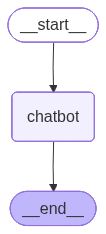

In [15]:
graph_compiled

In [16]:
graph_compiled.invoke(state)


----------->Entering chatbot:
================================== Ai Message ==================================

Certainly! Here's a classic grook by Piet Hein:

```
Losing One Glove

Losing one glove
is certainly painful,
but nothing
compared to the pain
of losing one,
throwing away the other,
and finding
the first one again.
```

Piet Hein's grooks are known for their brevity and wit, often conveying deep insights with simplicity.


{'messages': [AIMessage(content="Certainly! Here's a classic grook by Piet Hein:\n\n```\nLosing One Glove\n\nLosing one glove\nis certainly painful,\nbut nothing\ncompared to the pain\nof losing one,\nthrowing away the other,\nand finding\nthe first one again.\n```\n\nPiet Hein's grooks are known for their brevity and wit, often conveying deep insights with simplicity.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 17, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d59908c1a9', 'id': 'chatcmpl-DWGhCjlszhCkn1RDC1Oay1G0MY6tV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da499-f401-7543-b3b8-5cb15b64538c-0', tool_cal

In [17]:
%mypy

Success: no issues found in 1 source file
Type checking successful
